# PSNR vs Compression Ratio — Hurricane (multi-field aux, Phase-1 BO + Phase-2 sweep)

**Dataset:** Hurricane ISABEL, base (non-log10) fields, each 100×500×500 float32.

**Per target field:**

1. **Phase 1 — BO (Optuna TPE)** on a cheap proxy picks the best `lr` (direction fixed to **Z** — the only square-slice axis here).
2. **Phase 2 — ablation** with that `lr`, sweeping the SZ3 bound `REL_ERRS` (moves CR) × model size `PARAM_TARGETS` (separate curves).  **No early-stop.**

**Aux fields:** the other fields' **raw (uncompressed)** values are fed as extra **input** channels (`n_fields = 1 target + aux`), like the NYX multi-field setup.

```
CR = target_orig_bytes / (sz_target_bytes + n_params * 2)   # aux SZ3 NOT charged
```

Aux is raw side-info (not compressed, not charged to CR); only the target's SZ3 stream + the model count toward the target's CR.

In [1]:
import random, sys, os, glob, copy, time
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.append("/home/sam/Halo_Finder/Final_design/base_script")

# Force-reload edited modules so re-running this cell picks up bg_stage.py changes
# WITHOUT restarting the kernel (Jupyter caches modules in sys.modules).
import importlib
import bg_stage
importlib.reload(bg_stage)

from experiment import build_bg_only_cfg, estimate_bg_model_param_bytes
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
from bg_shard import pick_bg_h_under_budget

pysz_dir = "/home/sam/Data_Compression/SZ3/tools/pysz"
if pysz_dir not in sys.path:
    sys.path.append(pysz_dir)
from pysz import SZ

def set_seed(seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPUs: {torch.cuda.device_count()}")

Device: cuda:0 | GPUs: 1


/home/sam/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = "/home/sam/Halo_Finder/halo_finder_v1/100x500x500"
sz_lib_path = "/home/sam/Data_Compression/SZ3/build/lib64/libSZ3c.so"

# ── Dataset constants ──────────────────────────────────────────────────────────
data_shape  = (100, 500, 500)
TARGET_STEM = "hurricane"
DTYPE       = np.float32

# Quick-test downsample: stride>1 shrinks each field (and re-compresses it) so the
# sweep runs fast.  CR is then computed on the shrunk field.  Set to 1 for full res.
SPATIAL_STRIDE = 1

sz_engine = SZ(sz_lib_path)
print("SZ engine loaded")

SZ engine loaded


In [3]:
def load_field(path, stride=1):
    """Load one 100x500x500 float32 field (optionally strided)."""
    vol = np.fromfile(path, dtype=DTYPE).reshape(data_shape)
    if stride > 1:
        vol = np.ascontiguousarray(vol[::stride, ::stride, ::stride])
    return vol

def compress_at(vol, rel_err):
    """SZ3-compress `vol` at a relative-error bound; return (Xps, sz_bytes, sz_cr)."""
    b, cr = sz_engine.compress(vol, 1, 0, float(rel_err), 0)
    x_lq  = sz_engine.decompress(b, vol.shape, DTYPE)
    return [np.asarray(x_lq, np.float32)], int(len(b)), float(cr)

def psnr_from_arrays(target, recon):
    data_range = float(target.max() - target.min())
    if data_range <= 0:
        data_range = 1.0
    mse = float(np.mean((target - recon) ** 2))
    return 100.0 if mse <= 0 else 20.0 * np.log10(data_range) - 10.0 * np.log10(mse)

In [4]:
# Data layout (D, H, W).  Permute so the chosen slice axis becomes axis-0 (the
# "depth" the BG model iterates over); the other two axes are the 2-D patch.
DIRECTIONS = ["Z"]   # 100x500x500 is anisotropic: only Z gives square 500x500
                     # slices.  The BG sampler needs square patches, and Y/X would
                     # slice the thin 100-axis (non-square, not meaningful here).
_DIR_AXIS  = {"Z": 0, "Y": 1, "X": 2}
_FWD = {"Z": (0, 1, 2), "Y": (1, 0, 2), "X": (2, 0, 1)}
_INV = {"Z": (0, 1, 2), "Y": (1, 0, 2), "X": (1, 2, 0)}

def permute_fields(fields, direction):
    axes = _FWD[direction]
    if axes == (0, 1, 2):
        return fields
    return [np.ascontiguousarray(np.transpose(f, axes)) for f in fields]

def unpermute_field(field, direction):
    axes = _INV[direction]
    if axes == (0, 1, 2):
        return field
    return np.ascontiguousarray(np.transpose(field, axes))

def make_proxy(fields, direction, n_keep, S):
    """Cheap Phase-1 proxy: take n_keep planes along `direction` first, then
    permute, stride-downsample the two spatial dims, and crop them to a multiple
    of 8 (the Micro-UNet does two stride-2 halvings; a 250 patch breaks the skip
    concat: 250 -> 125 -> 63 -> upsample 126 != 125)."""
    axis = _DIR_AXIS[direction]
    n    = fields[0].shape[axis]
    idx  = np.unique(np.linspace(0, n - 1, min(n_keep, n)).round().astype(int))
    out  = []
    for f in fields:
        sub = np.take(f, idx, axis=axis)
        sub = np.transpose(sub, _FWD[direction])
        sub = sub[:, ::S, ::S]
        h = max(8, (sub.shape[1] // 8) * 8)
        w = max(8, (sub.shape[2] // 8) * 8)
        out.append(np.ascontiguousarray(sub[:, :h, :w]))
    return out

print("Direction helpers ready")

Direction helpers ready


In [5]:
# Base (non-log10) f32 fields only
all_f32      = sorted(glob.glob(os.path.join(DATA_DIR, "*.bin.f32")))
base_paths   = [p for p in all_f32 if ".log10." not in os.path.basename(p)]
base_names   = [os.path.basename(p).replace(".bin.f32", "") for p in base_paths]
name_to_path = dict(zip(base_names, base_paths))

# Target field(s) to STUDY (one model + R-D curve each)
TARGET_FIELDS = ["PRECIPf48"]

# Auxiliary INPUT fields: the other base fields' RAW (uncompressed) values feed
# the model as extra channels (like NYX).  Set AUX_FIELDS = [] for single-field.
# Aux is raw side-info: not compressed, not charged to CR.
AUX_FIELDS = ["CLOUDf48", "Pf48", "TCf48", "Uf48", "Vf48", "Wf48"]
AUX_FIELDS = [a for a in AUX_FIELDS if a in base_names and a not in TARGET_FIELDS]
N_FIELDS   = 1 + len(AUX_FIELDS)        # model input channels (target + aux)

print(f"Targets ({len(TARGET_FIELDS)}): {TARGET_FIELDS}")
print(f"Aux fields ({len(AUX_FIELDS)}): {AUX_FIELDS}")
print(f"Model input channels n_fields = {N_FIELDS}")

Targets (1): ['PRECIPf48']
Aux fields (6): ['CLOUDf48', 'Pf48', 'TCf48', 'Uf48', 'Vf48', 'Wf48']
Model input channels n_fields = 7


In [6]:
def build_cfg(Xs_in, Xps_in, max_train_time, bg_h, steps_per_epoch,
              lr=1e-4, epochs=200, log_prefix="", patch_size=None):
    if patch_size is None:
        patch_size = Xs_in[0].shape[2]
    cfg = build_bg_only_cfg(
        X_target=Xs_in[0], Xps=Xps_in, max_train_time=max_train_time,
        epochs=epochs, steps_per_epoch=steps_per_epoch, bg_h=bg_h,
        bg_batch=1, bg_patch_size=patch_size, lr=lr,
    )
    cfg.bg_sample_mode   = "sequential"
    cfg.bg_log_prefix    = log_prefix
    cfg.bg_arch          = "spatial"
    cfg.amp              = True
    cfg.amp_dtype        = "bf16"
    cfg.bg_ddp           = False
    cfg.bg_data_parallel = False
    return cfg

def n_params_of(model):
    return int(sum(p.numel() for p in unwrap_bg_model(model).parameters()))

# GT cache (each field loaded once; aux fields reused across targets/rel-errs)
_gt_cache = {}
def get_gt(name):
    if name not in _gt_cache:
        _gt_cache[name] = load_field(name_to_path[name], SPATIAL_STRIDE)
    return _gt_cache[name]

def compress_multi(names, rel):
    """SZ3-compress ONLY the target (names[0]); aux fields (names[1:]) are passed
    as RAW (uncompressed) input, like the NYX multi-field setup.
    Returns (Xps_list, target_sz_bytes)."""
    tgt_lq, tgt_sz, _ = compress_at(get_gt(names[0]), rel)
    xps = [tgt_lq[0]] + [get_gt(a) for a in names[1:]]   # target SZ3 + raw aux
    return xps, tgt_sz

print("Helpers ready")

Helpers ready


## Phase 1 — Bayesian Optimization (per target field × rel-error)

Optuna TPE searches `lr ∈ [1e-4, 1e-2]` (log) on a cheap multi-field proxy (`TUNE_DEPTH` slices, `S_SPATIAL` stride, fixed small param budget; direction fixed to **Z**).  Each trial trains to `PER_TRIAL_CAP` (time cap — **no early-stop**); objective = final proxy PSNR.  Phase 1 runs **once per rel_err**, at the same SZ3 bound as the Phase 2 run it feeds, so the picked `lr` matches the operating point (the proxy uses the same aux fields too).

In [7]:
# ── Phase 1 knobs ─────────────────────────────────────────────────────────────
PHASE1_TIME       = 3.0      # wall-clock budget for the BO search, per target
N_TRIALS_P1       = 10        # max trials per target
TUNE_DEPTH        = 16        # proxy slices kept per trial
S_SPATIAL         = 2         # proxy spatial stride
PARAM_BUDGET_TUNE = 3000     # proxy model size (lr transfers across sizes)

def run_phase1_bo(Xs, Xps, rel_err, phase1_time=PHASE1_TIME,
                  n_trials=N_TRIALS_P1, freq_warmup=20):
    """Proxy BO over lr (direction fixed by DIRECTIONS); returns (best_lr, best_dir, study).
    Xs = [target_gt], Xps = [target_lq, aux1_lq, ...] (multi-field)."""
    proxy_cache = {d: (make_proxy(Xs, d, TUNE_DEPTH, S_SPATIAL),
                       make_proxy(Xps, d, TUNE_DEPTH, S_SPATIAL)) for d in DIRECTIONS}
    proxy_shape = proxy_cache[DIRECTIONS[0]][0][0].shape
    n_fields    = len(Xps)
    try:
        bg_h_tune = int(pick_bg_h_under_budget(
            PARAM_BUDGET_TUNE, shape=proxy_shape, n_fields=n_fields, bg_arch="spatial")[0])
    except Exception:
        bg_h_tune = 10
    per_trial = phase1_time / max(1, n_trials)

    def objective(trial):
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        d  = trial.suggest_categorical("direction", DIRECTIONS)
        A, B = proxy_cache[d]
        cfg = build_cfg(A, B, max_train_time=per_trial, bg_h=bg_h_tune,
                        steps_per_epoch=A[0].shape[0], lr=lr, epochs=999,
                        log_prefix=f"P1-proxy-{d}-{lr:.0e}", patch_size=A[0].shape[2])
        cfg.bg_freq_warmup_epochs = freq_warmup       # no early-stop in Phase 1
        def ev(m, c=cfg, A=A, B=B):
            xh = run_bg_inference(unwrap_bg_model(m), A, B, c, rel_err)
            return psnr_from_arrays(A[0], xh), 0.0
        set_seed(42)
        _, hist = train_bg_only(Xs=A, Xps=B, device=device, cfg=cfg, evaluator=ev)
        ps = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
        return ps[-1] if ps else -1.0

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, n_startup_trials=4))
    for d in DIRECTIONS:
        study.enqueue_trial({"lr": 1e-3, "direction": d})
    study.optimize(objective, n_trials=n_trials, timeout=phase1_time)
    return study.best_params["lr"], study.best_params["direction"], study


def run_phase1_all_rels(gt, field_order, rel_errs,
                        phase1_time=PHASE1_TIME, n_trials=N_TRIALS_P1):
    """Run a SEPARATE Phase-1 BO for EACH rel_err.

    Every rel_err is SZ3-compressed independently (target SZ3 + raw aux) so its BO
    sees the exact error bound its Phase-2 run will use. Returns the per-rel learning
    rate / slice direction: {rel: (best_lr, best_dir)}.
    """
    lr_by_rel = {}
    for rel in rel_errs:
        Xps_list, _ = compress_multi(field_order, rel)
        best_lr, best_dir, _ = run_phase1_bo([gt], Xps_list, rel_err=rel,
                                             phase1_time=phase1_time, n_trials=n_trials)
        lr_by_rel[rel] = (best_lr, best_dir)
        print(f"  [Phase1] rel={rel:.0e} -> lr={best_lr:.2e} dir={best_dir}")
    return lr_by_rel


print(f"Phase 1 ready | {PHASE1_TIME:.0f}s, <= {N_TRIALS_P1} trials, proxy "
      f"{TUNE_DEPTH} slices / stride {S_SPATIAL} | a separate BO runs per rel_err")

Phase 1 ready | 3s, <= 10 trials, proxy 16 slices / stride 2 | a separate BO runs per rel_err


## Phase 2 — size × rel-error ablation (per target field)

Using the BO-picked `lr` (direction Z), sweep `REL_ERRS` × `PARAM_TARGETS` at full resolution, **no early-stop**.  `steps_per_epoch` = the full slice count along the Phase-1 direction (Z → 100), so each epoch iterates every 500×500 slice once.  The model sees `N_FIELDS` input channels (target + aux); CR charges only the target's SZ3 stream + model bytes.

In [8]:
# ── Phase 2 fixed knobs ───────────────────────────────────────────────────────
TIME_PER_CONFIG = 5         # fixed wall-clock budget per model (no early-stop)
BYTES_PER_PARAM = 2             # bf16 storage for the model weights
FREQ_WARMUP     = 1           # epochs before the FFT/freq loss term joins the loss

# Outer sweep: SZ3 relative-error bound (this is what actually moves CR)
REL_ERRS = [1e-4, 3e-4, 5e-4, 7e-4, 9e-4]

# Inner sweep: model parameter budgets (separate curves)
PARAM_TARGETS = [3000, 6000, 9000, 13000]
H_CANDIDATES  = list(range(3, 80))

# Map each budget -> largest bg_h that fits (uses the real n_fields incl. aux)
_seen = set()
sweep_plan = []          # list of (bg_h, est_params)
for tgt in PARAM_TARGETS:
    h, est_p = pick_bg_h_under_budget(
        tgt, shape=data_shape, n_fields=N_FIELDS,
        bg_arch="spatial", h_candidates=H_CANDIDATES,
    )
    if h not in _seen:
        _seen.add(h)
        sweep_plan.append((int(h), int(est_p)))
sweep_plan.sort()

n_p2 = len(TARGET_FIELDS) * len(REL_ERRS) * len(sweep_plan)
print(f"Phase 2: {TIME_PER_CONFIG:.0f}s/config | n_fields={N_FIELDS} | freq_warmup={FREQ_WARMUP}")
print(f"Targets: {len(TARGET_FIELDS)} | REL_ERRS: {REL_ERRS}")
print(f"Model sizes ({len(sweep_plan)} distinct):")
for h, est_p in sweep_plan:
    print(f"  bg_h={h:2d}  ~{est_p:,} params")
print(f"\n>> {n_p2} Phase-2 trainings (~{n_p2*TIME_PER_CONFIG/3600:.1f} h) "
      f"+ {len(TARGET_FIELDS)*len(REL_ERRS)} Phase-1 BO searches (one per target × rel_err)")


[Model: spatial] Total Params: 886
 [Params] Main (BG) Network : 886 parameters

[Model: spatial] Total Params: 1,432
 [Params] Main (BG) Network : 1,432 parameters

[Model: spatial] Total Params: 2,104
 [Params] Main (BG) Network : 2,104 parameters

[Model: spatial] Total Params: 2,902
 [Params] Main (BG) Network : 2,902 parameters

[Model: spatial] Total Params: 3,826
 [Params] Main (BG) Network : 3,826 parameters

[Model: spatial] Total Params: 4,876
 [Params] Main (BG) Network : 4,876 parameters

[Model: spatial] Total Params: 6,052
 [Params] Main (BG) Network : 6,052 parameters

[Model: spatial] Total Params: 7,354
 [Params] Main (BG) Network : 7,354 parameters

[Model: spatial] Total Params: 8,782
 [Params] Main (BG) Network : 8,782 parameters

[Model: spatial] Total Params: 10,336
 [Params] Main (BG) Network : 10,336 parameters

[Model: spatial] Total Params: 12,016
 [Params] Main (BG) Network : 12,016 parameters

[Model: spatial] Total Params: 13,822
 [Params] Main (BG) Networ

In [9]:
# Reload bg_stage so re-running ONLY this cell picks up edits.
import importlib, bg_stage
importlib.reload(bg_stage)
from bg_stage import run_bg_inference, train_bg_only, unwrap_bg_model
print(f"bg_stage OK: {bg_stage.__file__}\n")

results_by_field   = {}   # target -> list of dicts(rel, bg_h, n_params, psnr, cr, ...)
baselines_by_field = {}   # target -> list of dicts(rel, cr, psnr, sz_mb)
phase1_by_field    = {}   # target -> (best_lr, best_direction)

# GPU warm-up (not timed)
_w_vol = get_gt(TARGET_FIELDS[0])
_w_Xps, _, _ = compress_at(_w_vol, max(REL_ERRS))
_wcfg = build_cfg([_w_vol], _w_Xps, max_train_time=0.5, bg_h=4,
                  steps_per_epoch=2, lr=1e-3, epochs=1, log_prefix="warmup")
set_seed(42)
train_bg_only(Xs=[_w_vol], Xps=_w_Xps, device=device, cfg=_wcfg,
              evaluator=lambda m, c=_wcfg: (0.0, 0.0))
torch.cuda.synchronize() if torch.cuda.is_available() else None
del _w_Xps
print("GPU warm-up done\n")

sweep_t0 = time.time()
for fi, target in enumerate(TARGET_FIELDS):
    gt          = get_gt(target)
    orig_bytes  = gt.nbytes
    field_order = [target] + AUX_FIELDS          # target first, aux after
    print(f"\n{'='*64}")
    print(f"[target {fi+1}/{len(TARGET_FIELDS)}] {target}  shape={gt.shape}  "
          f"n_fields={len(field_order)} (1 target + {len(AUX_FIELDS)} aux)")

    # ── Phase 1: a SEPARATE BO per rel_err -> {rel: (best_lr, best_dir)} ──────
    t_p1 = time.time()
    lr_by_rel = run_phase1_all_rels(gt, field_order, REL_ERRS)
    print(f"  Phase 1 done in {time.time()-t_p1:.0f}s for {len(REL_ERRS)} rel_errs")

    # ── Phase 2: per rel_err, full-data size sweep using THAT rel's Phase-1 lr ─
    res, base = [], []
    for rel in REL_ERRS:
        # SZ3 compression at this rel (target SZ3 + raw aux) for baseline + Phase 2.
        Xps_list, sz_bytes = compress_multi(field_order, rel)
        base_psnr = psnr_from_arrays(gt, Xps_list[0])
        base_cr   = orig_bytes / sz_bytes
        base.append(dict(rel=rel, cr=base_cr, psnr=base_psnr, sz_mb=sz_bytes/1e6))

        best_lr, best_dir = lr_by_rel[rel]
        print(f"  rel={rel:.0e}: SZ3 CR={base_cr:.1f}x base PSNR={base_psnr:.2f} dB | "
              f"Phase1 lr={best_lr:.2e} dir={best_dir}")

        Xs_p  = permute_fields([gt], best_dir)
        Xps_p = permute_fields(Xps_list, best_dir)
        depth_p, patch_p = Xs_p[0].shape[0], Xs_p[0].shape[2]
        for bg_h, est_p in sweep_plan:
            cfg = build_cfg(Xs_p, Xps_p, max_train_time=TIME_PER_CONFIG, bg_h=bg_h,
                            steps_per_epoch=depth_p, lr=best_lr, epochs=200,
                            log_prefix=f"P2-{target}-r{rel:.0e}-h{bg_h}", patch_size=patch_p)
            cfg.bg_early_stop          = False   # ablation: full budget, no early-stop
            cfg.bg_freq_warmup_epochs  = FREQ_WARMUP

            def evaluator(m, c=cfg, A=Xs_p, B=Xps_p, g=gt, d=best_dir, r=rel):
                xh_p = run_bg_inference(unwrap_bg_model(m), A, B, c, r)
                xh   = unpermute_field(xh_p, d)
                return psnr_from_arrays(g, xh), 0.0

            set_seed(42)
            model, hist = train_bg_only(Xs=Xs_p, Xps=Xps_p, device=device,
                                        cfg=cfg, evaluator=evaluator)
            n_params  = n_params_of(model)
            psnr_vals = [v[1] if isinstance(v, tuple) else v for v in hist.get("psnr", [])]
            psnr      = max(psnr_vals) if psnr_vals else float("nan")
            cr        = orig_bytes / (sz_bytes + n_params * BYTES_PER_PARAM)   # aux NOT charged
            res.append(dict(rel=rel, bg_h=bg_h, n_params=n_params, psnr=psnr, cr=cr,
                            lr=best_lr, epochs=len(hist.get("loss", []))))
            print(f"      bg_h={bg_h:2d} ({n_params:,}p): PSNR={psnr:.2f} dB | CR={cr:.1f}x "
                  f"(+{psnr-base_psnr:.2f} over SZ3)")
            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
        del Xps_list, Xps_p, Xs_p

    results_by_field[target]   = res
    baselines_by_field[target] = base
    phase1_by_field[target]    = lr_by_rel
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print(f"\n--- All done in {(time.time()-sweep_t0)/60:.1f} min "
      f"({len(results_by_field)} targets) ---")

bg_stage OK: /home/sam/Halo_Finder/Final_design/base_script/bg_stage.py


[Model: spatial] Total Params: 1,216
 [Params] Main (BG) Network : 1,216 parameters
warmup [Init] Epoch   0 | Global PSNR: 0.00 dB | MaxErr: 0.0
warmup [plan] pure_train_budget=0.50s | epochs_cap=1 | steps/epoch=2 | patch=500 | batch=1 | sample=sequential | data_parallel=False | amp=bf16
warmup [early-stop] DISABLED (cfg.bg_early_stop is False/unset)
warmup [gpu-sampling] 1 fields resident on cuda:0 (~0.2 GB)


/home/sam/Halo_Finder/Final_design/base_script/bg_stage.py:522: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp, dtype=autocast_dtype):


warmup Epoch   1 [BG] | train_wall=2.26s | Loss: 1.514112 | Freq: 3.609375 | Global: 0.00 dB | MaxErr: 0.0
warmup [timing] first_epoch_pure_train≈2.292s (excludes this epoch's end-of-epoch eval)

warmup --- Experiment [BG_only] finished ---
warmup --- Pure training time: 2.29 s ---
warmup [timing] epochs=1 | train_wall/epoch: mean=2.26s min=2.26s max=2.26s | sum=2.26s
warmup --- Best global PSNR: 0.00 dB ---
GPU warm-up done


[target 1/1] PRECIPf48  shape=(100, 500, 500)  n_fields=7 (1 target + 6 aux)

[Model: spatial] Total Params: 886
 [Params] Main (BG) Network : 886 parameters

[Model: spatial] Total Params: 1,432
 [Params] Main (BG) Network : 1,432 parameters

[Model: spatial] Total Params: 2,104
 [Params] Main (BG) Network : 2,104 parameters

[Model: spatial] Total Params: 2,902
 [Params] Main (BG) Network : 2,902 parameters

[Model: spatial] Total Params: 3,826
 [Params] Main (BG) Network : 3,826 parameters

[Model: spatial] Total Params: 4,876
 [Params] Main (BG) Network : 4,8

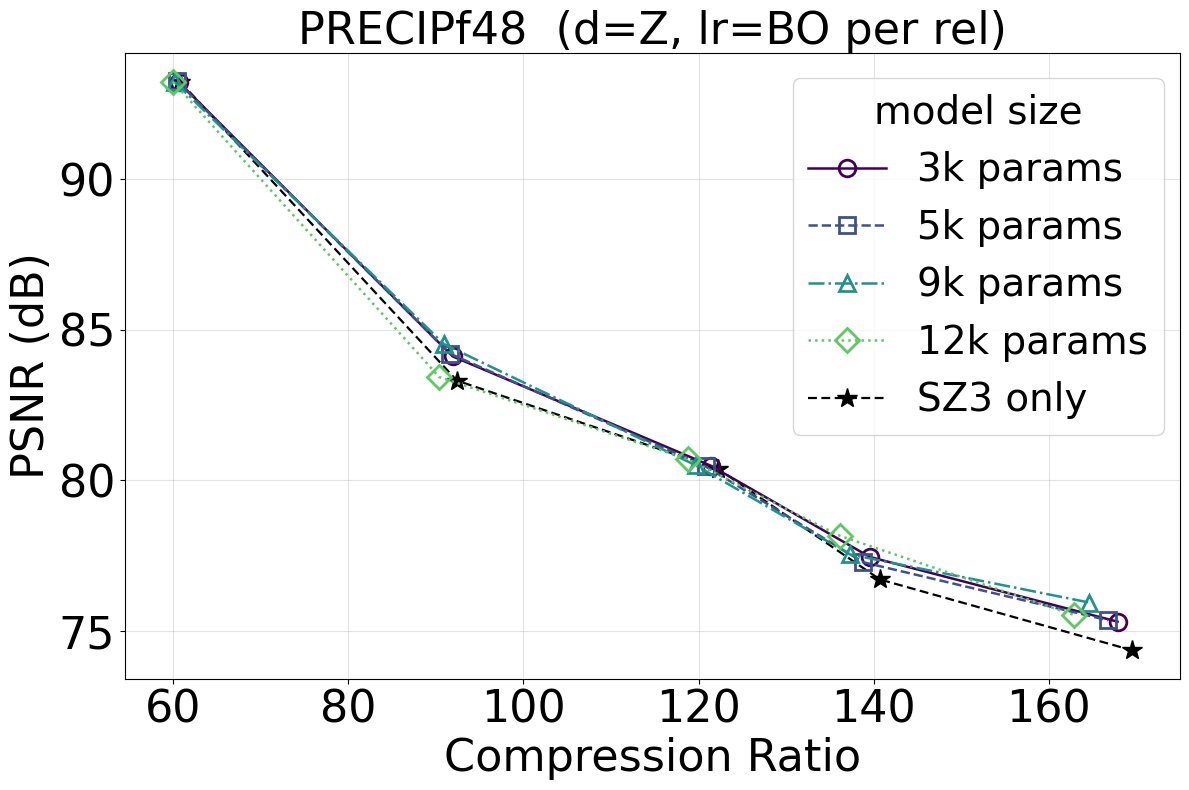

Saved: psnr_vs_cr_relsweep_hurricane_aux.pdf

### PRECIPf48   (dir=Z, lr=BO per rel, n_fields=7)
    rel        lr  bg_h     params  PSNR(dB)       CR     +dB
  1e-04   5.6e-04     6      2,902     93.23     60.6    0.01
  1e-04   5.6e-04     8      4,876     93.24     60.5    0.02
  1e-04   5.6e-04    11      8,782     93.22     60.2    0.00
  1e-04   5.6e-04    13     12,016     93.24     60.0    0.02
  3e-04   2.9e-03     6      2,902     84.12     91.9    0.80
  3e-04   2.9e-03     8      4,876     84.21     91.6    0.90
  3e-04   2.9e-03    11      8,782     84.52     90.9    1.21
  3e-04   2.9e-03    13     12,016     83.43     90.4    0.12
  5e-04   1.0e-03     6      2,902     80.49    121.4    0.11
  5e-04   1.0e-03     8      4,876     80.47    120.8    0.08
  5e-04   1.0e-03    11      8,782     80.50    119.7    0.12
  5e-04   1.0e-03    13     12,016     80.71    118.8    0.32
  7e-04   1.0e-03     6      2,902     77.46    139.6    0.75
  7e-04   1.0e-03     8      4,876 

In [10]:
fields = [f for f in TARGET_FIELDS if f in results_by_field]
param_sizes = sorted(set(r["n_params"] for fl in results_by_field.values() for r in fl))

# 【改动 1：避免黄色】
cmap = plt.cm.viridis
# 乘以 0.75，把取值范围限制在 [0, 0.75]，避开 viridis 末端的亮黄色
colors = {p: cmap((i / max(1, len(param_sizes) - 1)) * 0.75) for i, p in enumerate(param_sizes)}

# Distinct marker shape + line style per curve (cycled if there are more curves)
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "p"]
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1)), (0, (1, 1))]

def fmt_p(p):
    return f"{p/1000:.0f}k" if p >= 1000 else str(p)

ncols = min(4, len(fields))
nrows = int(np.ceil(len(fields) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), squeeze=False)

for idx, fname in enumerate(fields):
    ax  = axes[idx // ncols][idx % ncols]
    res = results_by_field[fname]
    for i, p in enumerate(param_sizes):
        pts = sorted([r for r in res if r["n_params"] == p], key=lambda r: r["cr"])
        if pts:
            ax.plot([r["cr"] for r in pts], [r["psnr"] for r in pts],
                    marker=MARKERS[i % len(MARKERS)],
                    linestyle=LINESTYLES[i % len(LINESTYLES)],
                    color=colors[p], 
                    
                    # 【改动 2：空心 + 放大 marker】
                    markerfacecolor='none',  # 空心填充
                    markeredgewidth=2.0,     # 边缘稍微加粗
                    markersize=12,           # 放大 marker
                    
                    linewidth=1.8, zorder=3,
                    label=f"{fmt_p(p)} params")
            
    # SZ3-only baseline curve
    bl = sorted(baselines_by_field[fname], key=lambda b: b["cr"])
    ax.plot([b["cr"] for b in bl], [b["psnr"] for b in bl],
            marker="*", linestyle=(0, (4, 2)), color="black",
            markersize=15, linewidth=1.6, zorder=2,
            label="SZ3 only")
            
    p1 = phase1_by_field.get(fname, {})
    bdir = next(iter(p1.values()))[1] if p1 else "?"
    
    ax.set_title(f"{fname}  (d={bdir}, lr=BO per rel)", fontsize=32)
    ax.set_xlabel("Compression Ratio", fontsize=32)
    ax.set_ylabel("PSNR (dB)", fontsize=32)
    ax.tick_params(axis='both', which='major', labelsize=32)
    ax.grid(True, alpha=0.35)

for j in range(len(fields), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

handles, labels = axes[0][0].get_legend_handles_labels()
# 统一的图例
fig.legend(handles, labels, loc="upper right", fontsize=28, title="model size", title_fontsize=28,
           bbox_to_anchor=(0.99, 0.92))  # 第二个数字越小，图例越往下

# 取消了 fig.suptitle，使得图表更干净
plt.tight_layout()
out_pdf = f"psnr_vs_cr_relsweep_{TARGET_STEM}_aux.pdf"
plt.savefig(out_pdf, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")

# Full table per target (lr is BO-tuned per rel_err)
for fname in fields:
    p1 = phase1_by_field.get(fname, {})
    bdir = next(iter(p1.values()))[1] if p1 else "?"
    print(f"\n### {fname}   (dir={bdir}, lr=BO per rel, n_fields={N_FIELDS})")
    print(f"{'rel':>7} {'lr':>9} {'bg_h':>5} {'params':>10} {'PSNR(dB)':>9} {'CR':>8} {'+dB':>7}")
    base_by_rel = {b['rel']: b for b in baselines_by_field[fname]}
    for r in sorted(results_by_field[fname], key=lambda r: (r['rel'], r['n_params'])):
        b = base_by_rel[r['rel']]
        print(f"{r['rel']:>7.0e} {r.get('lr', float('nan')):>9.1e} {r['bg_h']:>5} "
              f"{r['n_params']:>10,} {r['psnr']:>9.2f} {r['cr']:>8.1f} {r['psnr']-b['psnr']:>7.2f}")
